![imagen](real_state.png)

# Exercise 1

The purpose of this notebook is to demonstrate how to use the features of Python libraries to explore a dataset.

# 1. Import libraries

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load data

In [13]:
data=pd.read_csv('venta_inmuebles_data.csv',sep=',')

In [14]:
data.head()

,numero_cuartos,numero_baños,area_de_ construcción_pie2,area_del lote_pie2,numero_pisos,condición,grado,superficie_sótano_pie2,año_de_construcción,precio
0,3,1,1180,5650,1,3,7,0,1955,221900
1,2,1,770,10000,1,3,6,0,1933,180000
2,4,3,1960,5000,1,5,7,910,1965,604000
3,3,2,1680,8080,1,3,8,0,1987,510000
4,3,1,1780,7470,1,3,7,730,1960,229500


In [15]:
data.shape

(5466, 10)

### I get a first look at the data, such as its descriptive statistics and distributions

In [16]:
data.describe()

,numero_cuartos,numero_baños,area_de_ construcción_pie2,area_del lote_pie2,numero_pisos,condición,grado,superficie_sótano_pie2,año_de_construcción,precio
count,5466.000000,5466.00000,5466.000000,5.466000e+03,5466.000000,5466.000000,5466.000000,5466.000000,5466.000000,5.466000e+03
mean,2.929382,1.53659,1498.602452,1.332597e+04,1.174716,3.454812,6.923710,199.205452,1957.169411,3.876553e+05
std,0.955433,0.73386,681.509065,4.500415e+04,0.420896,0.695475,0.910364,359.221943,26.314611,1.790408e+05
min,0.000000,0.00000,290.000000,6.000000e+02,1.000000,1.000000,1.000000,0.000000,1900.000000,7.500000e+04
25%,2.000000,1.00000,1020.000000,5.100000e+03,1.000000,3.000000,6.000000,0.000000,1942.000000,2.510000e+05
50%,3.000000,1.00000,1320.000000,7.351000e+03,1.000000,3.000000,7.000000,0.000000,1955.000000,3.500000e+05
75%,3.000000,2.00000,1780.000000,9.714750e+03,1.000000,4.000000,7.000000,300.000000,1973.750000,4.798000e+05
max,11.000000,6.00000,7120.000000,1.651359e+06,3.000000,5.000000,12.000000,2196.000000,2015.000000,2.000000e+06


In [24]:
data.dtypes

numero_cuartos                int64
numero_baños                  int64
area_de_ construcción_pie2    int64
area_del lote_pie2            int64
numero_pisos                  int64
condición                     int64
grado                         int64
superficie_sótano_pie2        int64
año_de_construcción           int64
precio                        int64
dtype: object

In [39]:
data['numero_baños'].value_counts()

numero_baños
1    3218
2    1612
3     564
4      56
0       8
5       7
6       1
Name: count, dtype: int64

In [40]:
data['numero_pisos'].value_counts()

numero_pisos
1    4601
2     775
3      90
Name: count, dtype: int64

### Charts

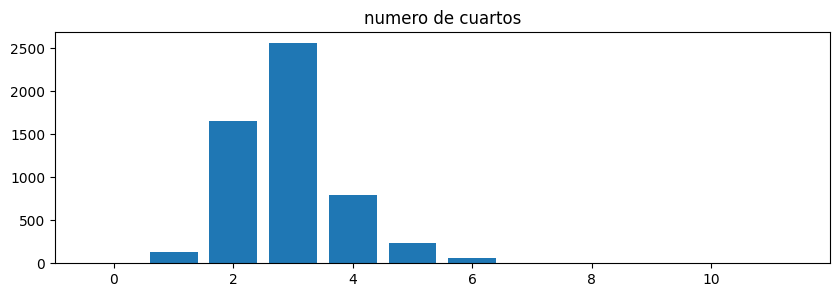

In [30]:
plt.figure(figsize=(10,3))
plt.bar(data['numero_cuartos'].unique(),data['numero_cuartos'].value_counts())  
plt.title('numero de cuartos')  
plt.show()

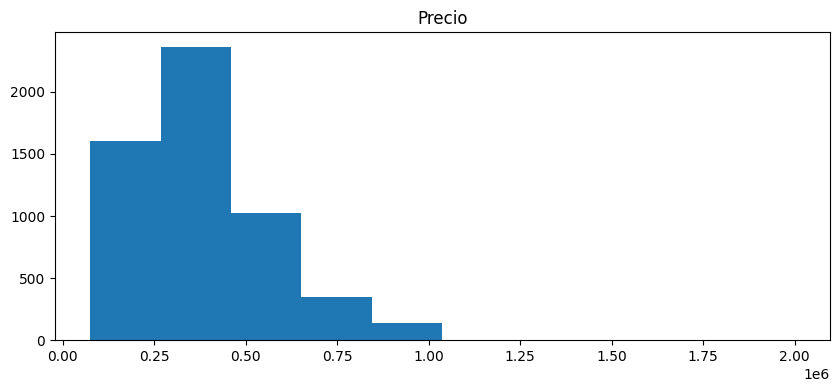

In [37]:
plt.figure(figsize=(10,4))
plt.hist(data['precio'], bins=10)
plt.title('Precio')  
plt.show()

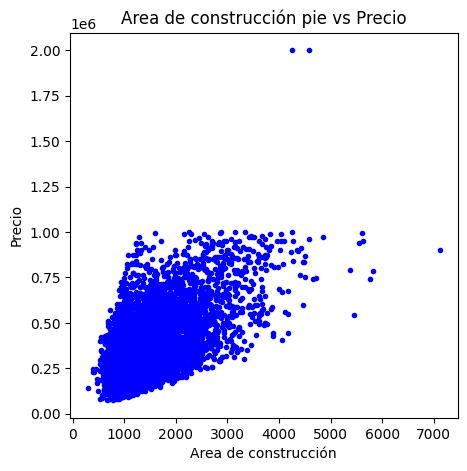

In [32]:
plt.figure(figsize=(5,5))
plt.plot(data['area_de_ construcción_pie2'],data['precio'],'.', color='blue')
plt.title('Area de construcción pie vs Precio')
plt.xlabel('Area de construcción')  
plt.ylabel('Precio')  
plt.show()

<Axes: xlabel='precio', ylabel='Count'>

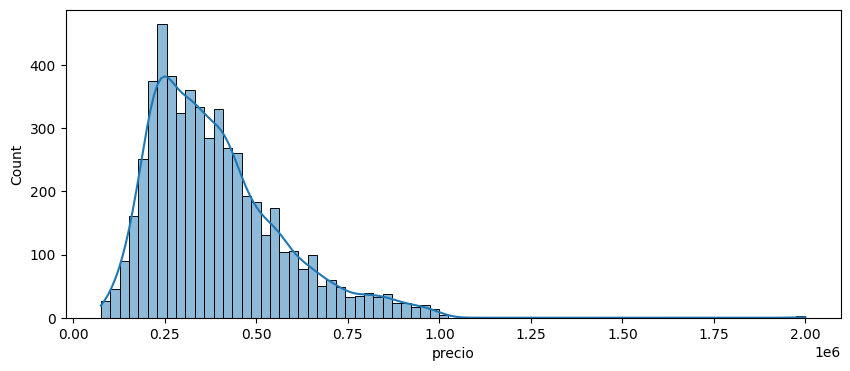

In [21]:
plt.figure(figsize=(10,4))
plt.tight_layout()
sns.histplot(data['precio'], kde=True)

### The following library allows me to generate a descriptive analysis of the dataset with a single command

In [22]:
from ydata_profiling import ProfileReport

In [41]:
profile = ProfileReport(
    data, 
    title="Reporte de Análisis - Dataset Data",
    explorative=True 
)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 949.73it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### Exploratory Data Analysis (EDA) Conclusions

#### Data Quality
- No missing values were found in the dataset.
- One duplicate row was identified and should be removed.

### Variable Distributions
- The variables `numero_cuartos`, `area_de_construcción_pie2`, and `grado` have distributions that approximate normality, suggesting they represent central phenomena in the data.
- The `numero_pisos` variable shows significant imbalance (55.4% for a predominant value), which could affect its predictive utility.
- The `superficie_sótano_pie2` variable has 3,771 zeros (69.0%), indicating that most properties do not have a basement. This could be treated as a categorical variable (with/without basement) rather than numerical.

### Variable Relationships (Correlations)

#### Strong Correlations (> 0.6)

| Variable | Strongly Correlates With |
|----------|------------------------------|
| `area_de_construcción_pie2` | `grado` (0.627), `numero_baños` (0.727), `numero_cuartos` (0.676) |
| `grado` | `area_de_construcción_pie2` (0.627), `numero_baños` (0.553), `precio` (0.536) |
| `numero_baños` | `area_de_construcción_pie2` (0.727), `grado` (0.553), `numero_cuartos` (0.574) |
| `numero_cuartos` | `area_de_construcción_pie2` (0.676), `numero_baños` (0.574) |

#### Key Observations
- `precio` is moderately correlated with `grado` (0.536). This is the highest correlation with the target variable, suggesting that property grade could be an important predictor.
- `area_del_lote_pie2` has a weak negative correlation with `precio` (-0.124), indicating that larger lots do not necessarily imply higher prices in this dataset.
- `año_de_construcción` shows an almost null correlation with `precio` (0.005). Property age alone does not explain significant variations in price.
- `condición` shows low correlations with all variables (maximum 0.169), suggesting it might be less relevant for prediction.